Data Science Fundamentals for DCBP, University of Bern

In [42]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from requests.packages import package

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

DATA_DIR = Path("data")
ARTIFACT_DIR = DATA_DIR / Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python Version: ",sys.version)
from print_versions import print_versions
print_versions(globals())

Python Version:  3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]
pandas==3.0.2
matplotlib==3.10.9
numpy==2.4.4
rdkit==2026.3.1


# CodingTask 2: Polymer Feature Hunt

- Submission format: notebook only (`.ipynb`)
- Work style: individual or small teams of up to 3 allowed
- Focus: **chemistry-driven feature engineering** and interpretation of model failures
- Prerequisites: artifacts from CodingTask 1 (`artifacts/ffv_features_rdkit.csv`) -- the notebook below rebuilds it from `data/train.csv` if missing

- **Deadline**: 2026-05-17, 23:59 (send your notebook by email to matteo.boi@unibe.ch)
- **On-site review/experiment lecture**: 2026-05-20
- Estimated effort: 4-6 hours

---

## What this task is about

1. **Why** you picked the chemical features you picked
2. **What** your model gets wrong, on **which** polymers, and **why** (interpretation of failure cases)

So spend most of your effort on the *reasoning*, not on the *code*.

## Points (12.5 total + up to 1 bonus)

| Component | Pts | What earns full credit |
|---|---|---|
| CT2.1 Feature picking | 6.0 | At least 5 new features, each with a one-sentence justification |
| CT2.2 Outlier interpretation | 4.0 | 5 worst polymers identified, structures drawn, **structural hypothesis** is specific (functional groups, ring systems, chain length, etc.) |
| Participation in May 20 session | 2.5 | Asks at least one question OR proposes a feature OR contributes to discussion |
| **Bonus** -- alt model / sweep | +1.0 | Reasonable alternative model attempted with brief discussion |


---
## Loading the dataset

The task uses the same dataset and split as Notebook 13. The cell below rebuilds `artifacts/ffv_features_rdkit.csv` from `data/train.csv` if it is missing, so you can run this notebook even if you skipped some of CodingTask 1.

In [43]:
# Add MolWt, NumValenceElectrons and TPSA
train_df = pd.read_csv("data/artifacts/train_ffv_imported.csv")
train_plus_df = train_df.copy()
def rdkit_row(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return [np.nan, np.nan, np.nan]
        return [Descriptors.MolWt(mol),
                Descriptors.NumValenceElectrons(mol),
                Descriptors.TPSA(mol)]

rdkit_vals = np.array([rdkit_row(s) for s in train_plus_df["SMILES"]])
train_plus_df["MolWt"]                 = rdkit_vals[:, 0]
train_plus_df["NumValenceElectrons"]   = rdkit_vals[:, 1]
train_plus_df["TPSA"]                  = rdkit_vals[:, 2]

# switch "train" and "valid" labels cause it was the wrong way around
train_plus_df.replace("train", "temp", inplace=True)
train_plus_df.replace("valid", "train", inplace=True)
train_plus_df.replace("temp", "valid", inplace=True)

,index,id,SMILES,FFV,SMILES_Length,Stars,Carbons,Oxygens,Nitrogens,Equals,split,MolWt,NumValenceElectrons,TPSA
0,2800,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,36,8,0,6,temp,680.781,234.0,120.88
1,7684,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,32,0,2,0,temp,458.734,184.0,24.06
2,7779,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,44,2,2,2,temp,618.736,228.0,43.18
3,3444,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,20,3,2,2,temp,338.407,130.0,67.43
4,4618,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,8,1,0,0,temp,120.151,46.0,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,4256,1150090312,*C(=O)Nc1ccc(NC(=O)c2ccc3c(c2)C(=O)N(c2cc(-c4n...,0.371324,94,2,37,6,5,6,valid,661.655,234.0,145.85
7026,5887,1596743017,*C=C*,0.425737,5,2,2,0,0,1,valid,26.038,10.0,0.00
7027,5928,1608343989,*CC(*)C(=O)OCCCCSC,0.397873,18,2,8,2,0,1,valid,174.265,64.0,26.30
7028,6116,1658493417,*Nc1ccc(C2=C3CC=CC=C3[C@H](c3ccc(N*)cc3)c3cccc...,0.369994,53,2,26,0,2,3,valid,360.460,134.0,24.06


,index,id,SMILES,FFV,SMILES_Length,Stars,Carbons,Oxygens,Nitrogens,Equals,split,MolWt,NumValenceElectrons,TPSA
0,2800,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,36,8,0,6,temp,680.781,234.0,120.88
1,7684,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,32,0,2,0,temp,458.734,184.0,24.06
2,7779,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,44,2,2,2,temp,618.736,228.0,43.18
3,3444,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,20,3,2,2,temp,338.407,130.0,67.43
4,4618,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,8,1,0,0,temp,120.151,46.0,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,4256,1150090312,*C(=O)Nc1ccc(NC(=O)c2ccc3c(c2)C(=O)N(c2cc(-c4n...,0.371324,94,2,37,6,5,6,train,661.655,234.0,145.85
7026,5887,1596743017,*C=C*,0.425737,5,2,2,0,0,1,train,26.038,10.0,0.00
7027,5928,1608343989,*CC(*)C(=O)OCCCCSC,0.397873,18,2,8,2,0,1,train,174.265,64.0,26.30
7028,6116,1658493417,*Nc1ccc(C2=C3CC=CC=C3[C@H](c3ccc(N*)cc3)c3cccc...,0.369994,53,2,26,0,2,3,train,360.460,134.0,24.06


,index,id,SMILES,FFV,SMILES_Length,Stars,Carbons,Oxygens,Nitrogens,Equals,split,MolWt,NumValenceElectrons,TPSA
0,2800,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,36,8,0,6,valid,680.781,234.0,120.88
1,7684,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,32,0,2,0,valid,458.734,184.0,24.06
2,7779,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,44,2,2,2,valid,618.736,228.0,43.18
3,3444,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,20,3,2,2,valid,338.407,130.0,67.43
4,4618,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,8,1,0,0,valid,120.151,46.0,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,4256,1150090312,*C(=O)Nc1ccc(NC(=O)c2ccc3c(c2)C(=O)N(c2cc(-c4n...,0.371324,94,2,37,6,5,6,train,661.655,234.0,145.85
7026,5887,1596743017,*C=C*,0.425737,5,2,2,0,0,1,train,26.038,10.0,0.00
7027,5928,1608343989,*CC(*)C(=O)OCCCCSC,0.397873,18,2,8,2,0,1,train,174.265,64.0,26.30
7028,6116,1658493417,*Nc1ccc(C2=C3CC=CC=C3[C@H](c3ccc(N*)cc3)c3cccc...,0.369994,53,2,26,0,2,3,train,360.460,134.0,24.06


---
## CT2.1 Feature engineering (6.0 pts)

The baseline dataset already contains three RDKit descriptors: `MolWt`, `NumValenceElectrons`, and `TPSA`. Your job: **add at least 5 more descriptors of your own choice**.

How to find them: read the RDKit `Descriptors` module documentation, search online, look at papers on polymer property prediction. There are dozens of options.

For **each** descriptor you pick, write **one sentence** explaining why it might affect Fractional Free Volume (FFV) -- the fraction of empty space in a polymer. Generic statements like "this is a useful feature" do **not** earn credit. The justification should connect what the descriptor measures to a plausible structural reason for FFV going up or down.

Create a pandas DataFrame that contains the new descriptors you chose.

Save the resulting DataFrame as `artifacts/ffv_features_extended.csv` (the variable name `extended_df` is used by the sanity-check cell at the end of the notebook).

In [44]:
ffv_extended = train_plus_df.copy()

##### YOUR CODE STARTS HERE #####
# TODO: Add at least 5 more descriptors to extended_df.
def rdkit_add(smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [np.nan, np.nan, np.nan, np.nan, np.nan
                    ]
        return [Chem.rdMolDescriptors.CalcNumAliphaticRings(mol),
                Chem.rdMolDescriptors.CalcNumAromaticRings(mol),
                Chem.rdMolDescriptors.CalcNumRotatableBonds(mol),
                0.5*Chem.rdMolDescriptors.CalcNumLipinskiHBA(mol)+0.5*Chem.rdMolDescriptors.CalcNumLipinskiHBD(mol),
                Chem.GraphDescriptors.BalabanJ(mol, dMat=None, forceDMat=0),
                ]
rdkit_vals = np.array([rdkit_add(s) for s in ffv_extended["SMILES"]])

ffv_extended["AliphRings"]          = rdkit_vals[:, 0]
ffv_extended["AroRings"]            = rdkit_vals[:, 1]
ffv_extended["Rotatable_Bonds"]     = rdkit_vals[:, 2]
ffv_extended["H_Bonds"]             = rdkit_vals[:, 3]
ffv_extended["Balaban_J_value"]     = rdkit_vals[:, 4]

ffv_extended_df=ffv_extended.copy()
display(ffv_extended_df)
####

,index,id,SMILES,FFV,SMILES_Length,Stars,Carbons,Oxygens,Nitrogens,Equals,split,MolWt,NumValenceElectrons,TPSA,AliphRings,AroRings,Rotatable_Bonds,H_Bonds,Balaban_J_value
0,2800,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,36,8,0,6,valid,680.781,234.0,120.88,0.0,6.0,10.0,4.0,1.122686
1,7684,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,32,0,2,0,valid,458.734,184.0,24.06,2.0,2.0,7.0,2.0,1.987370
2,7779,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,44,2,2,2,valid,618.736,228.0,43.18,0.0,7.0,10.0,2.0,1.124664
3,3444,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,20,3,2,2,valid,338.407,130.0,67.43,0.0,2.0,10.0,3.5,1.549501
4,4618,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,8,1,0,0,valid,120.151,46.0,9.23,0.0,1.0,3.0,0.5,2.738499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,4256,1150090312,*C(=O)Nc1ccc(NC(=O)c2ccc3c(c2)C(=O)N(c2cc(-c4n...,0.371324,94,2,37,6,5,6,train,661.655,234.0,145.85,2.0,6.0,6.0,6.5,1.157821
7026,5887,1596743017,*C=C*,0.425737,5,2,2,0,0,1,train,26.038,10.0,0.00,0.0,0.0,0.0,0.0,2.549193
7027,5928,1608343989,*CC(*)C(=O)OCCCCSC,0.397873,18,2,8,2,0,1,train,174.265,64.0,26.30,0.0,0.0,7.0,1.0,3.266441
7028,6116,1658493417,*Nc1ccc(C2=C3CC=CC=C3[C@H](c3ccc(N*)cc3)c3cccc...,0.369994,53,2,26,0,2,3,train,360.460,134.0,24.06,2.0,3.0,4.0,2.0,1.723590


In [45]:
# Save the extended features to a new CSV file in the artifacts directory.
extended_path = ARTIFACT_DIR / "ffv_extended_df.csv"
ffv_extended_df.to_csv(extended_path, index=False)
print("Saved:", extended_path)

Saved: data/artifacts/ffv_extended_df.csv


### Reasoning

List each descriptor you picked and write **one sentence** explaining why it could plausibly affect FFV. Mention what the descriptor measures *and* the structural reason FFV would go up or down because of it.

<span style="color:pink">

Since the FFV is calculated with the van-der-Waals Volume, the following features are likely to have an impact on the vdW-volume.
- Aliphatic Rings: Aliphatic Rings are 3D structures that can greatly impact the vdW-volume, especially with any substituents they might have.
- Aromatic Rings: Aromatic rings are flat and can interact with other molecules or atoms due to their electron-dense ring either via attraction or repulsion.
- Rotatable Bonds: Rotatable Bonds can allow the molecule to reform itself which can creates a larger or smaller FFV.
- H-Bonds: These specific polar intermolecular bonds can decrease FFV by creating such a bond within the same molecule or also increase it by expanding it to another molecule.
- Balaban J-Values: This is an index describing the topology of a molecule, this way, the topology can give hints into how tightly packed or long-stretched a molecule is.

</span>

---
## Train a Random Forest with your features

This part is just so you have a model whose predictions you can look at. You do not need to tune it deeply -- a default `RandomForestRegressor` is fine. 

Steps:
1. Build `X_train`, `y_train`, `X_valid`, `y_valid` from the `split` column.
2. Train `RandomForestRegressor(n_estimators=200, random_state=42)` on the training set.
3. Compute MAE, RMSE, and R² on the validation set, and print them. **The validation R² is what gets you on the leaderboard.**

In [46]:
#####
# TODO: Create:
# - the feature matrix X_train and target vector y_train for the training split.
# - the feature matrix X_valid and target vector y_valid for the validation split.
# Use the 'split' column to separate train/valid, and remove the 'id', 'SMILES', 'FFV', and 'split' columns from the features.

##### YOUR CODE STARTS HERE #####
# this line is here only because I didn't wanna run the cells before again
extended_path = ARTIFACT_DIR / "ffv_extended_df.csv"
ffv_extended_df = pd.read_csv(extended_path)

#define features and targets (excluding 'Stars' since it's just a placeholder)
feature_cols = ["SMILES_Length","Carbons","Oxygens","Nitrogens","Equals","MolWt","NumValenceElectrons","TPSA","AliphRings","AroRings","Rotatable_Bonds","H_Bonds","Balaban_J_value",
                ]
target_col = "FFV"

#split into trianing and validation sets
train_mask = ffv_extended_df["split"] == "train"
valid_mask = ffv_extended_df["split"] == "valid"

# ".values" gives numpy arrays which scikit-learn expects
X_train = ffv_extended_df.loc[train_mask, feature_cols].values
y_train = ffv_extended_df.loc[train_mask, target_col].values
X_valid = ffv_extended_df.loc[valid_mask, feature_cols].values
y_valid = ffv_extended_df.loc[valid_mask, target_col].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print("Shapes:", X_train.shape, X_valid.shape)

X_train shape: (5624, 13)
y_train shape: (5624,)
X_valid shape: (1406, 13)
y_valid shape: (1406,)
Shapes: (5624, 13) (1406, 13)


In [47]:
# Train a Random Forest on (X_train, y_train), predict on X_valid,
# and print MAE, RMSE, and R² on the validation set.
# TODO: your code here

######
# RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

# MAE (mean absolute error), RMSE (mean squared error), R^2
mae_rf = mean_absolute_error(y_valid, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
r2_rf = r2_score(y_valid, y_pred_rf)

print(f"Random Forest Results:")
print(f"  MAE:       {mae_rf:.4f}")
print(f"  RMSE:      {rmse_rf:.4f}")
print(f"  R-squared: {r2_rf:.4f}")
######

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Random Forest Results:
  MAE:       0.0098
  RMSE:      0.0210
  R-squared: 0.5728


---
## Feature importance and iteration

Your first 5 descriptors were a **hypothesis**. Now check what the model *actually* used.

A trained Random Forest exposes a `feature_importances_` attribute -- one score per feature, telling you how much it contributed to the predictions. Plot or print them, ranked from most to least important.

Then **iterate**: change your descriptor set and see what happens. Drop the ones the RF ignored, add new candidates you did not try the first time, use more or fewer than 5. Retrain, re-check the R², re-check the importances. The goal is to converge on the feature set that works best for predicting FFV.

<Figure size 800x400 with 0 Axes>

<BarContainer object of 13 artists>

Text(0.5, 0, 'Feature importance')

Text(0.5, 1.0, 'Random Forest feature importances')

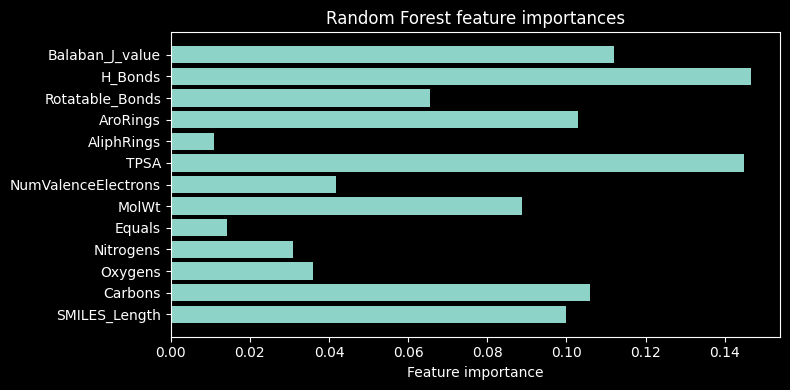

In [48]:
# Examine which features your Random Forest relied on the most.
# Use rf.feature_importances_ together with the column names of your X data,
# and plot or print them ranked from most to least important.
# TODO: your code here

######
# Importance
importances = rf.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_cols, importances)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()
######

### Try a different feature set

Now change your descriptors and see what improves:

- Drop the descriptors the RF barely used.
- Add at least **3 new descriptors** that you did not include in your first attempt.
- Feel free to use more (or fewer) than 5 descriptors in total.

Rebuild `extended_df`, retrain the Random Forest, and print the new validation R², MAE, RMSE together with the new feature-importance ranking. Try a couple of different combinations until you find a set you are happy with.

X_train shape: (5624, 16)
y_train shape: (5624,)
X_valid shape: (1406, 16)
y_valid shape: (1406,)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Random Forest Results:
  MAE:       0.0096
  RMSE:      0.0206
  R-squared: 0.5897


<Figure size 800x400 with 0 Axes>

<BarContainer object of 16 artists>

Text(0.5, 0, 'Feature importance')

Text(0.5, 1.0, 'Random Forest feature importances')

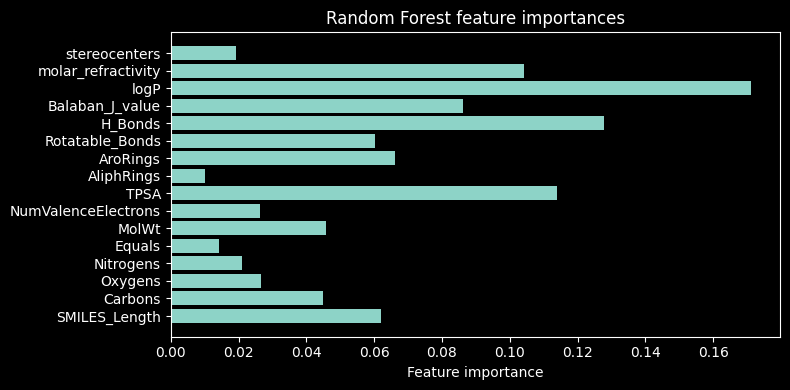

In [49]:
# Pick a different set of descriptors, rebuild extended_df, retrain the Random Forest,
# and print the new R², MAE, RMSE plus the new feature-importance ranking.
# Repeat with another combination if you want.
# TODO: your code here

######
# read csv
extended_path = ARTIFACT_DIR / "ffv_extended_df.csv"
ffv_extended_df = pd.read_csv(extended_path)

# add features
# log P = lipophilicity,
# mr_val = total polarizability of a mole of molecule
# stereocenters = Number of atomic stereocenters
mol_list = [Chem.MolFromSmiles(smiles) for smiles in ffv_extended_df["SMILES"]]
ari = [Chem.rdMolDescriptors.CalcCrippenDescriptors(moles) for moles in mol_list]
log_P = [t[0] for t in ari]
mr_val = [t[1] for t in ari]
ster_cent = [Chem.rdMolDescriptors.CalcNumAtomStereoCenters(moles) for moles in mol_list]
ffv_extended_df["logP"]                 = log_P
ffv_extended_df["molar_refractivity"]   = mr_val
ffv_extended_df["stereocenters"]        = ster_cent

#define features and targets
feature_cols = ["SMILES_Length","Carbons","Oxygens","Nitrogens","Equals","MolWt","NumValenceElectrons","TPSA","AliphRings","AroRings","Rotatable_Bonds","H_Bonds","Balaban_J_value","logP","molar_refractivity","stereocenters"]
target_col = "FFV"

#split into training and validation sets
train_mask = ffv_extended_df["split"] == "train"
valid_mask = ffv_extended_df["split"] == "valid"

# ".values" gives numpy arrays which scikit-learn expects
X_train = ffv_extended_df.loc[train_mask, feature_cols].values
y_train = ffv_extended_df.loc[train_mask, target_col].values
X_valid = ffv_extended_df.loc[valid_mask, feature_cols].values
y_valid = ffv_extended_df.loc[valid_mask, target_col].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")

######
# RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

# MAE (mean absolute error), RMSE (mean squared error), R^2
mae_rf = mean_absolute_error(y_valid, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
r2_rf = r2_score(y_valid, y_pred_rf)

print(f"Random Forest Results:")
print(f"  MAE:       {mae_rf:.4f}")
print(f"  RMSE:      {rmse_rf:.4f}")
print(f"  R-squared: {r2_rf:.4f}")
######

######
# Importance
importances = rf.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_cols, importances)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()
######
######

X_train shape: (5624, 15)
y_train shape: (5624,)
X_valid shape: (1406, 15)
y_valid shape: (1406,)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Random Forest Results:
  MAE:       0.0093
  RMSE:      0.0204
  R-squared: 0.5959


<Figure size 800x400 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 0, 'Feature importance')

Text(0.5, 1.0, 'Random Forest feature importances')

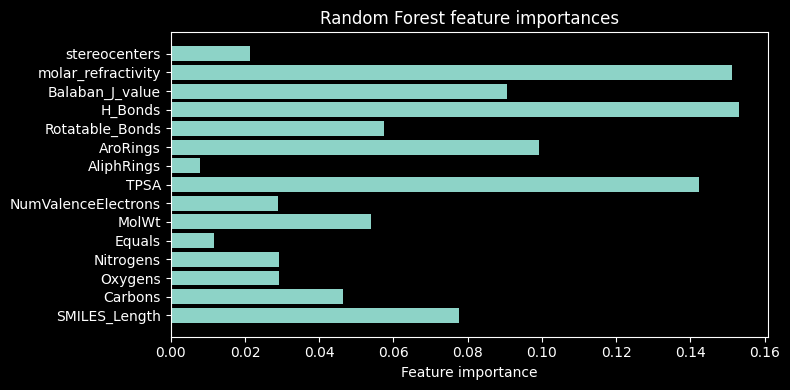

For importance >= 0.000, R-squared was 0.5897
For importance >= 0.025, R-squared was 0.5764
For importance >= 0.050, R-squared was 0.5643
For importance >= 0.075, R-squared was 0.5563
For importance >= 0.010, R-squared was 0.5334
Removing log(P), R-squared was 0.5959, so far, most desirable
Removing less important features decreased R-squared value


In [50]:
#####
# removing features and trying different combos
# feat_importance >=[insert value]
# removing [own notes]
original_feature_cols = [
    "SMILES_Length","Carbons","Oxygens","Nitrogens","Equals","MolWt","NumValenceElectrons","TPSA","AliphRings","AroRings","Rotatable_Bonds","H_Bonds","Balaban_J_value","logP","molar_refractivity","stereocenters"]
feature_cols =          [
    "SMILES_Length","Carbons","Oxygens","Nitrogens","Equals","MolWt","NumValenceElectrons","TPSA","AliphRings","AroRings","Rotatable_Bonds","H_Bonds","Balaban_J_value","molar_refractivity","stereocenters"]
target_col = "FFV"

#split into trianing and validation sets
train_mask = ffv_extended_df["split"] == "train"
valid_mask = ffv_extended_df["split"] == "valid"

# ".values" gives numpy arrays which scikit-learn expects
X_train = ffv_extended_df.loc[train_mask, feature_cols].values
y_train = ffv_extended_df.loc[train_mask, target_col].values
X_valid = ffv_extended_df.loc[valid_mask, feature_cols].values
y_valid = ffv_extended_df.loc[valid_mask, target_col].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")

######
# RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

# MAE (mean absolute error), RMSE (mean squared error), R^2
mae_rf = mean_absolute_error(y_valid, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
r2_rf = r2_score(y_valid, y_pred_rf)

print(f"Random Forest Results:")
print(f"  MAE:       {mae_rf:.4f}")
print(f"  RMSE:      {rmse_rf:.4f}")
print(f"  R-squared: {r2_rf:.4f}")
######

######
# Importance
importances = rf.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_cols, importances)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()
######
print("For importance >= 0.000, R-squared was 0.5897")
print("For importance >= 0.025, R-squared was 0.5764")
print("For importance >= 0.050, R-squared was 0.5643")
print("For importance >= 0.075, R-squared was 0.5563")
print("For importance >= 0.010, R-squared was 0.5334")
print("\x1b[95mRemoving log(P), R-squared was 0.5959, so far, most desirable\x1b[0m")
print("Removing less important features decreased R-squared value")
######

### Reflection

Look at the descriptors that ended up most important and compare them to the chemistry-driven hypotheses you wrote at the start.

- Were your initial guesses correct? Which descriptors did you *predict* would matter, and which *actually* did?
- Were any of the top-ranked descriptors a surprise? Try to come up with a chemistry-based explanation for why they could matter for FFV.
- Which final descriptor set are you submitting, and what is its best validation R²?

*Your reflection here (4-6 sentences).*

<span style="color:pink">

- Descriptors we thought would impact the FFV the most were the Balaban J-values, number of stereocenters and TPSA (topological polar surface area).
- Molar refractivity, H-bonds count and TPSA contributed the most.
- Since polarity can influence the FFV via intra- or intermolecular interactions, the top features being closely or directly related to polarity, makes sense.
- Unfortunately, the R-squared value only reached 0.5959.
- The submitted final descriptor is the following:
```
feature_cols = ["SMILES_Length","Carbons","Oxygens","Nitrogens","Equals","MolWt","NumValenceElectrons",
"TPSA","AliphRings","AroRings","Rotatable_Bonds","H_Bonds","Balaban_J_value",
"molar_refractivity","stereocenters"]
```
</span>

---
## CT2.2 Outlier investigation (4.0 pts)

Use your trained Random Forest to find the **5 polymers your model got most wrong** on the validation set. Then:

1. Compute the **absolute prediction error** for every validation polymer.
2. Pull the 5 polymers with the **largest** absolute error.
3. Draw their molecular structures with `Draw.MolsToGridImage` (look at Notebook 12 for the code to use). Include the true and predicted FFV in each legend.
4. **Write a 2-3 sentence structural hypothesis for each polymer**: what is unusual about its structure (functional groups, ring system, chain length, halogen content, charged groups, ...) that might make it hard to predict?

Vague answers like "the molecule is complex" do not earn credit. Be specific.

,index,id,SMILES,FFV,split,predicted_FFV,residuals
761,6064,1645416728,*CCC1C[N+](C)(C)CC1*,0.777097,valid,0.396131,0.380967
49,645,180321996,*CCCCCCCCCC[N+](*)(C)C,0.769315,valid,0.416403,0.352913
143,6689,1814521184,*CC(*)(C)C(=O)OCCO[N+](=O)[O-],0.495595,valid,0.282262,0.213333
1104,3143,852184111,*c1cc(C)c(*)s1,0.516864,valid,0.392182,0.124683
1361,5032,1365848174,*c1ccc(-c2nc3cc4nc(-c5ccccc5)c(*)nc4cc3nc2-c2c...,0.513982,valid,0.409778,0.104204


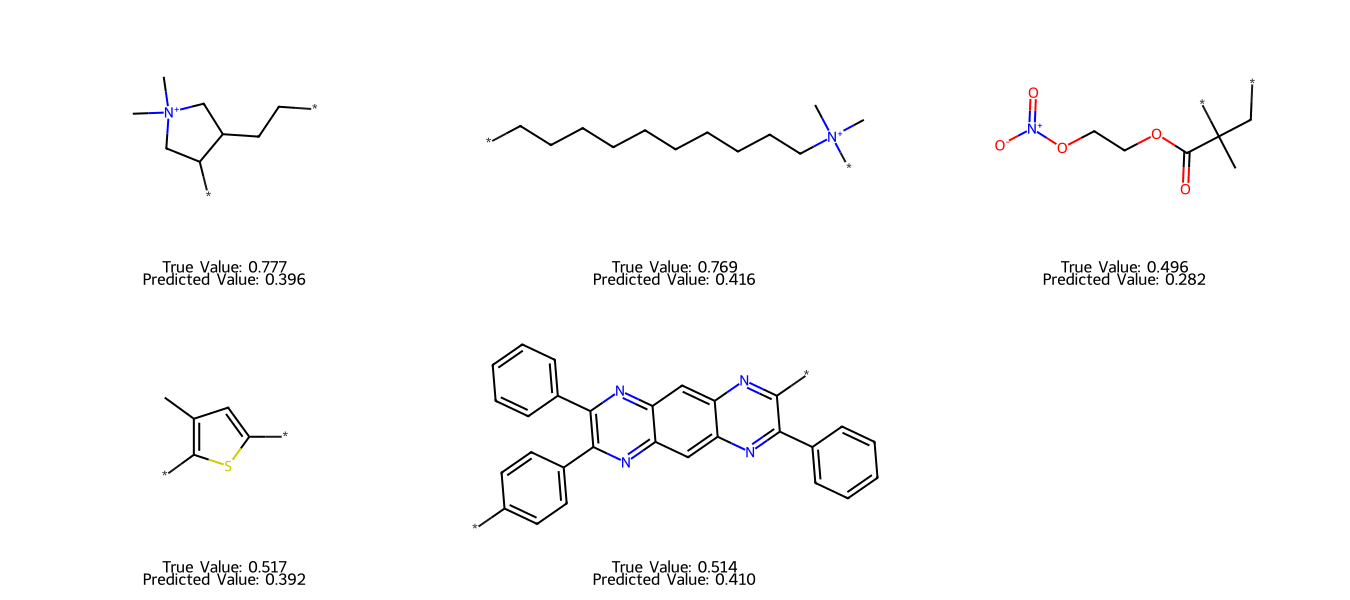

In [51]:
# Identify the 5 worst-predicted polymers in the validation set, draw their
# molecular structures in a grid, and label each with its true and predicted FFV.
# TODO: your code here

#make a list of predicted FFV values (fixing the np.float64 thingy)
y_pred=(y_pred_rf)
for i in range(len(y_pred)):
    y_pred[i]=float(y_pred[i])

# make a new dataframe with only the "valids" and remove feature columns for visibility
valid_df = ffv_extended_df[ffv_extended_df["split"]=="valid"]
valid_df=valid_df[["index","id","SMILES","FFV","split"]]
valid_df["predicted_FFV"]=y_pred

# find the worst error values and their indices
residuals = [valid - pred for valid, pred in zip(y_valid, y_pred_rf)]
worst_res=sorted(residuals, reverse=True)[:5]

worst_index=[]
for i in range(5):
    ix=residuals.index(worst_res[i])
    worst_index.append(ix)

# pick out the most badly predicted molecules and add a column with their differences
outlier_df=valid_df.iloc[worst_index]
outlier_df["residuals"]=worst_res
outlier_df.head()


# draw these molecules and show their error
True_FFV = [(f"True Value: {val:.3f}") for val in outlier_df["FFV"]]
Pred_FFV = [(f"Predicted Value: {val:.3f}") for val in outlier_df['predicted_FFV']]
molecule_legend = [(f"True Value: {true:.3f}\nPredicted Value: {pred:.3f}") for true,pred in zip(outlier_df["FFV"],outlier_df['predicted_FFV'])]
legend = [f"{True_FFV}\n{Pred_FFV}"]
mols = [Chem.MolFromSmiles(smiles) for smiles in outlier_df["SMILES"]]
Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(450, 300),legends=molecule_legend)

#arraybig = np.array(y_train,y_pred_rf,residuals)
#threshold = np.percentile(residuals, 99.7)
#worst_outliers = np.where(residuals > threshold)[0]
#print(worst_outliers)
#worst_molecule = ""

### Structural hypotheses (2-3 sentences per polymer)

For each of your 5 worst-predicted polymers, fill in a hypothesis. Refer to specific structural features.

<span style="color:pink">

1. Due to it's positively charged nitrogen, the polymer likely has a counteranion. Ionic bonds and interactions create a lot more space between other molecules which might explain the big difference in predicted FFV value.
2. Similar to Polymer 1. It also has a long aliphatic chain possibly hindering interactions.
3. The stars are very close together which would cause steric repulsion, especially with a polar head at the end. This polar head might also contribute to electronic repulsion.
4. The aromatic ring can delocalize electrons and thus would rather not be closed packed with other aromatic rings.
5. Similar to Polymer 4. Here the aromatic ring systems is much bigger and bulkier.

</span>


**Looking across all 5: do they share any common structural features?** (1-2 sentences)

<span style="color:pink">

All of them have heteroatoms but other than that they are different. Polymer 4 and 5 both have aromatic rings but the error of the prediction isn't as bad as with the top three. Polymer 1 and 2 are similar by having a positively charged nitrogen. Polymer 3 stands out for having a nitrate head.

</span>

---
## Bonus (+1.0 pt) -- try one alternative model OR a small hyperparameter sweep

Pick **one** of:

- A different model: `LinearRegression`, `GradientBoostingRegressor`, `HistGradientBoostingRegressor`, `MLPRegressor`, or LightGBM/XGBoost if you have them installed.
- A small hyperparameter sweep: 3-4 values of `max_depth` or `n_estimators` for the RF, with a plot of validation R² vs. that parameter.

Add 2-3 sentences interpreting the result: did it help? Why or why not?

In [52]:
# Optional bonus -- alternative model or hyperparameter sweep
# TODO: your code here


---
## Sanity checks

Run this cell after you finish CT2.1 -- this only checks that you produced the required outputs, not that they are *good*.

In [53]:
# 1) Extended features file saved
assert (ARTIFACT_DIR / "ffv_extended_df.csv").exists(), \
    "Missing artifacts/ffv_extended_df.csv"

# 2) At least 5 new descriptor columns beyond the original set
original_cols = set(pd.read_csv(ARTIFACT_DIR / "train_ffv_imported.csv").columns)
new_cols = set(ffv_extended_df.columns) - original_cols
assert len(new_cols) >= 5, f"Add at least 5 new descriptor columns (you added {len(new_cols)})"
print(f"You added {len(new_cols)} new descriptors: {sorted(new_cols)}")

# 3) X / y shapes are consistent
assert X_train.ndim == 2 and X_valid.ndim == 2, "X arrays must be 2D"
assert X_train.shape[1] == X_valid.shape[1], "X_train and X_valid must have the same number of columns"
assert X_train.shape[1] >= 1, "You need at least one feature column"
assert len(y_train) == X_train.shape[0]
assert len(y_valid) == X_valid.shape[0]

print("\nBasic checks passed -- you can submit.")

You added 11 new descriptors: ['AliphRings', 'AroRings', 'Balaban_J_value', 'H_Bonds', 'MolWt', 'NumValenceElectrons', 'Rotatable_Bonds', 'TPSA', 'logP', 'molar_refractivity', 'stereocenters']

Basic checks passed -- you can submit.


---
## Submission

- Submit only this notebook (rename to `CodingTask2_<your_name>.ipynb`) by **email** (matteo.boi@unibe.ch), by **Sunday 2026-05-17, 23:59**.
- Bring your laptop to class on **2026-05-20** -- we will pool everyone's features and experiment together live.